# Assignment 05 – Population by Sex, Age and Region in Ireland

This notebook uses the CSO dataset FY006A to analyse:

**Part 1**
- Weighted mean age by sex (Male vs Female)
- Difference between the sexes by age (Female − Male)
- Ignoring regions (Ireland as a whole)

**Part 2**
- Choose a target age (e.g. 35)
- Group all ages within 5 years of that age into one age band
- Calculate the population difference between the sexes in that age band

**Part 3**
- For that same age band,
- Find which region (administrative county) has the biggest population difference between the sexes

Part 1 – Weighted mean age by sex & difference by age

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

In [2]:
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en"
df_raw = pd.read_csv(url)

df_raw.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


In [3]:
# Start from the raw dataframe
df = df_raw.copy()

# Drop columns we don't need (BUT keep Sex, Single Year of Age, Administrative Counties, VALUE)
drop_col_list = [
    "STATISTIC",
    "Statistic Label",
    "TLIST(A1)",
    "CensusYear",
    "C02199V02655",
    "C02076V03371",
    "C03789V04537",
    "UNIT",
]
df.drop(columns=drop_col_list, inplace=True)

# Remove the 'All ages' row – we want single-year ages only
df = df[df["Single Year of Age"] != "All ages"]

# Turn "Under 1 year" into "0"
df["Single Year of Age"] = df["Single Year of Age"].str.replace("Under 1 year", "0")

# Keep only digits in age strings ("100 years and over" -> "100")
df["Single Year of Age"] = df["Single Year of Age"].str.replace(r"\D", "", regex=True)

# Convert to numbers
df["Single Year of Age"] = df["Single Year of Age"].astype("int64")
df["VALUE"] = df["VALUE"].astype("int64")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9696 entries, 32 to 9791
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Sex                      9696 non-null   object
 1   Single Year of Age       9696 non-null   int64 
 2   Administrative Counties  9696 non-null   object
 3   VALUE                    9696 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 378.8+ KB


,Sex,Single Year of Age,Administrative Counties,VALUE
32,Both sexes,0,Ireland,57796
33,Both sexes,0,Carlow County Council,699
34,Both sexes,0,Dublin City Council,6213
35,Both sexes,0,Dún Laoghaire Rathdown County Council,2457
36,Both sexes,0,Fingal County Council,4009


In [4]:
# Keep only Male and Female (ignore 'Both sexes')
df_sex = df[df["Sex"].isin(["Male", "Female"])].copy()

# Aggregate population by age and sex across all counties (Ireland total)
df_ireland_agesex = (
    df_sex
    .groupby(["Single Year of Age", "Sex"])["VALUE"]
    .sum()
    .reset_index(name="Population")
)

df_ireland_agesex.head()

,Single Year of Age,Sex,Population
0,0,Female,56372
1,0,Male,59220
2,1,Female,55090
3,1,Male,57750
4,2,Female,57948


In [5]:
df_anal = df_ireland_agesex.pivot(
    index="Single Year of Age",
    columns="Sex",
    values="Population"
).sort_index()

df_anal.head()

Sex,Female,Male
Single Year of Age,,
0,56372,59220
1,55090,57750
2,57948,60472
3,58966,62002
4,59638,63372


In [6]:
weighted_means = {}

for sex in ["Male", "Female"]:
    pop = df_anal[sex]
    ages = df_anal.index

    w_mean = np.average(ages, weights=pop)
    weighted_means[sex] = w_mean

weighted_means

{'Male': np.float64(37.7394477371039), 'Female': np.float64(38.9397958987787)}

In [7]:
for sex, w_mean in weighted_means.items():
    print(f"Weighted mean age for {sex}: {w_mean:.2f} years")

Weighted mean age for Male: 37.74 years
Weighted mean age for Female: 38.94 years


In [8]:
df_anal["Female_minus_Male"] = df_anal["Female"] - df_anal["Male"]

df_anal[["Female_minus_Male"]].head()

Sex,Female_minus_Male
Single Year of Age,
0,-2848
1,-2660
2,-2524
3,-3036
4,-3734


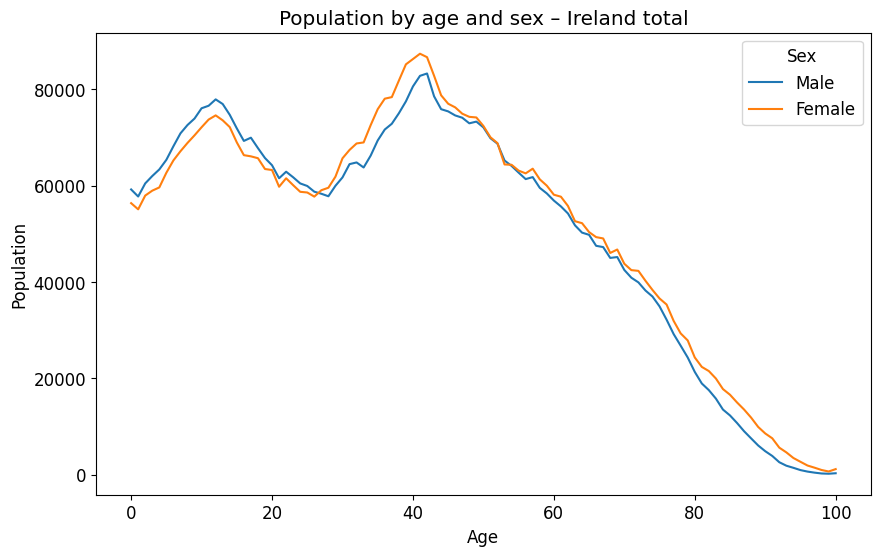

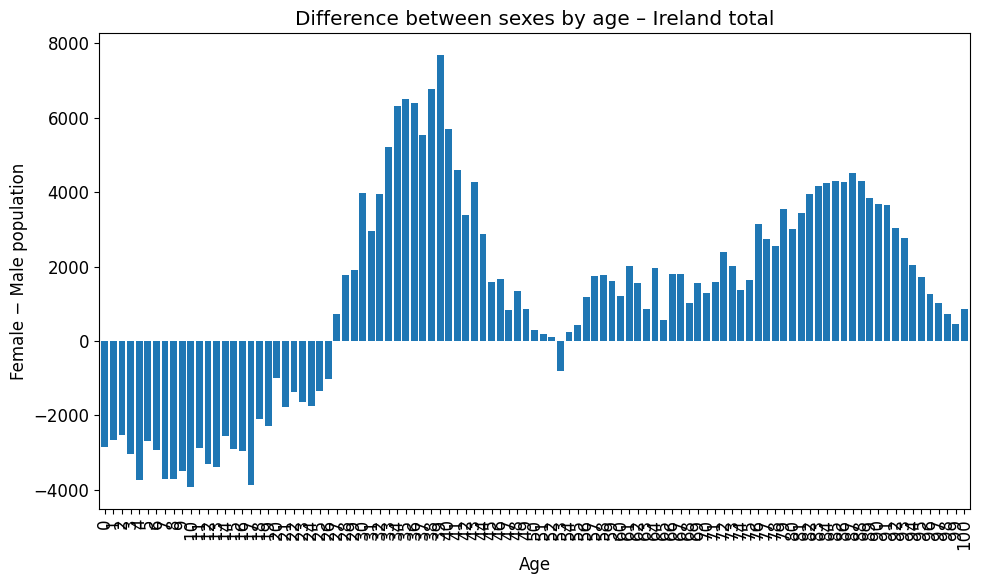

In [9]:
# Plot Male and Female populations by age
df_anal[["Male", "Female"]].plot()
plt.xlabel("Age")
plt.ylabel("Population")
plt.title("Population by age and sex – Ireland total")
plt.show()

# Plot difference (Female − Male) by age
df_anal["Female_minus_Male"].plot(kind="bar", width=0.8)
plt.xlabel("Age")
plt.ylabel("Female − Male population")
plt.title("Difference between sexes by age – Ireland total")
plt.tight_layout()
plt.show()

Part 2 – Difference in a 5-year window around a target age

In [10]:
# You can change this to any age you like
target_age = 35

lower_age = target_age - 5
upper_age = target_age + 5

print(f"Age band: {lower_age} to {upper_age} (inclusive)")

Age band: 30 to 40 (inclusive)


In [11]:
# Select the rows in the chosen age band
band = df_anal.loc[lower_age:upper_age, ["Male", "Female"]]

# Sum populations in that band
male_band = band["Male"].sum()
female_band = band["Female"].sum()

diff_band = female_band - male_band

print(f"Population in ages {lower_age}–{upper_age}:")
print(f"  Male:   {male_band:,}")
print(f"  Female: {female_band:,}")
print(f"\nPopulation difference (Female − Male) in this age band: {diff_band:,}")

Population in ages 30–40:
  Male:   768,060
  Female: 829,012

Population difference (Female − Male) in this age band: 60,952


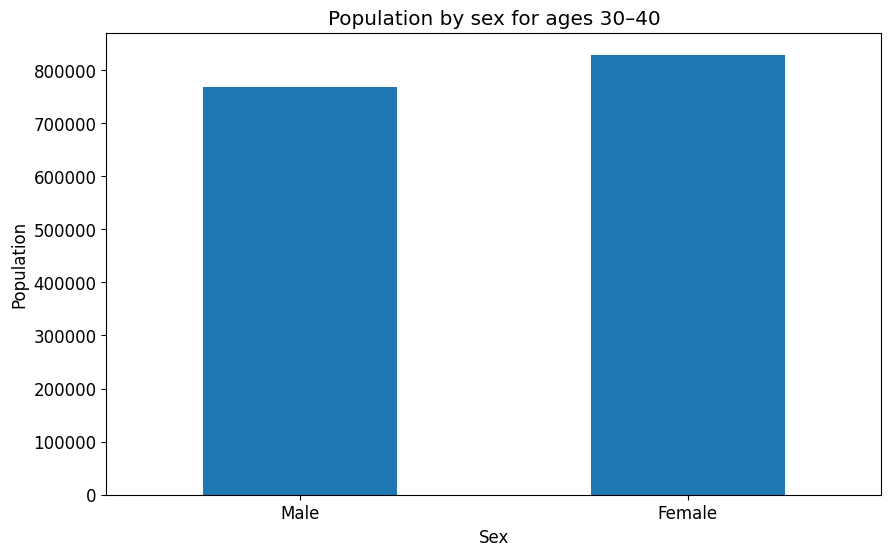

In [12]:
band_sum = band.sum()
band_sum.plot(kind="bar")
plt.ylabel("Population")
plt.title(f"Population by sex for ages {lower_age}–{upper_age}")
plt.xticks(rotation=0)
plt.show()

Part 3 – Region with the biggest sex difference in that age band

In [13]:
# Filter to the same age band but keep regions (counties)
df_band_regions = df_sex[
    (df_sex["Single Year of Age"] >= lower_age) &
    (df_sex["Single Year of Age"] <= upper_age)
].copy()

df_band_regions.head()

,Sex,Single Year of Age,Administrative Counties,VALUE
4256,Male,30,Ireland,30858
4257,Male,30,Carlow County Council,367
4258,Male,30,Dublin City Council,6163
4259,Male,30,Dún Laoghaire Rathdown County Council,1511
4260,Male,30,Fingal County Council,1888


In [14]:
# Total population in this age band for each region and sex
region_sex = (
    df_band_regions
    .groupby(["Administrative Counties", "Sex"])["VALUE"]
    .sum()
    .reset_index()
)

region_pivot = region_sex.pivot(
    index="Administrative Counties",
    columns="Sex",
    values="VALUE"
).fillna(0)

region_pivot.head()

Sex,Female,Male
Administrative Counties,,
Carlow County Council,4774,4451
Cavan County Council,6150,5776
Clare County Council,8896,8085
Cork City Council,19750,18812
Cork County Council,26545,23706


In [15]:
region_pivot["Female_minus_Male"] = region_pivot["Female"] - region_pivot["Male"]
region_pivot["abs_diff"] = region_pivot["Female_minus_Male"].abs()

region_pivot.sort_values("abs_diff", ascending=False).head()

Sex,Female,Male,Female_minus_Male,abs_diff
Administrative Counties,,,,
Ireland,414506,384030,30476,30476
Fingal County Council,29092,26150,2942,2942
Cork County Council,26545,23706,2839,2839
South Dublin County Council,26361,23637,2724,2724
Kildare County Council,20602,18671,1931,1931


In [16]:
max_region = region_pivot["abs_diff"].idxmax()
max_row = region_pivot.loc[max_region]

print(f"Region with the largest sex difference in ages {lower_age}–{upper_age}:")
print("-" * 60)
print(f"Region:              {max_region}")
print(f"Male population:     {int(max_row['Male']):,}")
print(f"Female population:   {int(max_row['Female']):,}")
print(f"Female − Male diff:  {int(max_row['Female_minus_Male']):,}")
print(f"Absolute difference: {int(max_row['abs_diff']):,}")

Region with the largest sex difference in ages 30–40:
------------------------------------------------------------
Region:              Ireland
Male population:     384,030
Female population:   414,506
Female − Male diff:  30,476
Absolute difference: 30,476


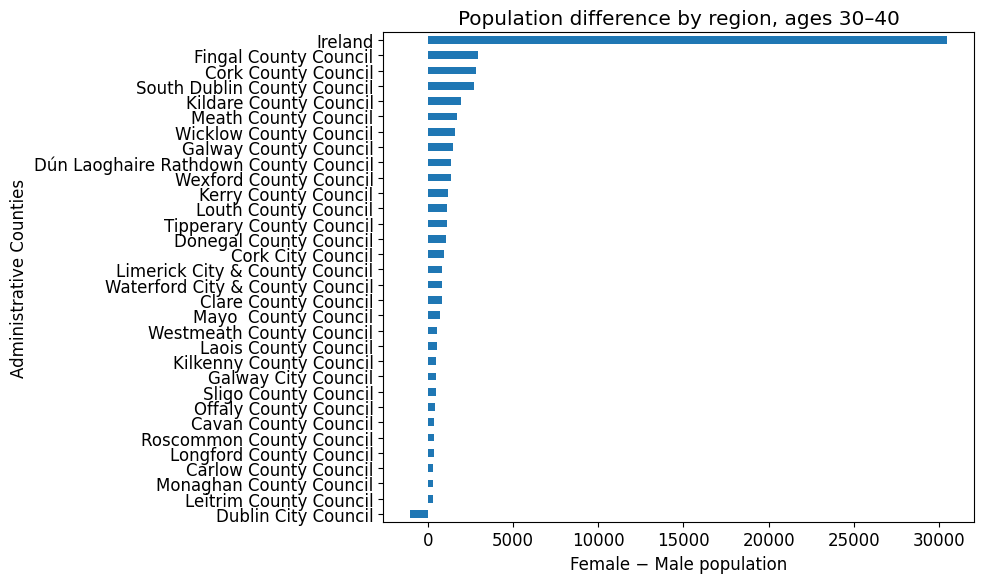

In [17]:
region_pivot["Female_minus_Male"].sort_values().plot(kind="barh")
plt.xlabel("Female − Male population")
plt.title(f"Population difference by region, ages {lower_age}–{upper_age}")
plt.tight_layout()
plt.show()